成功載入資料，共 12845 筆有效樣本。


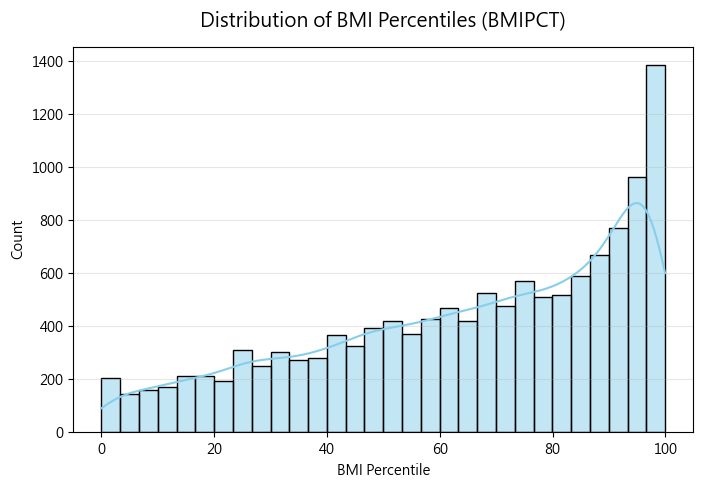

📷 已成功導出 outputs/figures/continuous_histogram.png


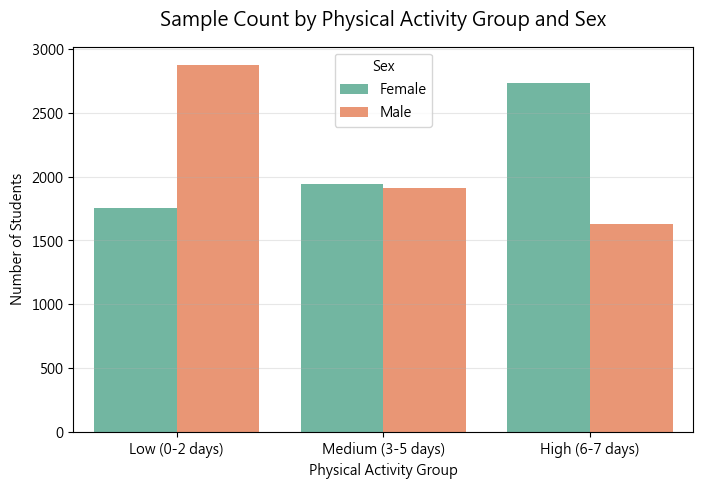

📷 已成功導出 outputs/figures/behavior_bar_chart.png
📊 已成功導出 outputs/tables/eda_summary_table.csv

--- 各組別 BMI 敘述統計摘要表格 ---
      Activity_Group Sex_Label  count       mean        std
0    High (6-7 days)    Female   2732  66.512765  26.711874
1    High (6-7 days)      Male   1629  60.842704  25.734524
2     Low (0-2 days)    Female   1752  65.760486  29.880678
3     Low (0-2 days)      Male   2876  64.857095  27.275813
4  Medium (3-5 days)    Female   1945  66.614920  28.337498
5  Medium (3-5 days)      Male   1911  63.243436  26.866673


In [28]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # 修正後的標準載入方式

# 設定 matplotlib 顯示中文與負號
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] # Windows 專用微軟正黑體
plt.rcParams['axes.unicode_minus'] = False

# 1. 直接讀取上一步產出的基礎清洗資料
cleaned_data_path = 'data/processed/yrbs_cleaned.csv'
df = pd.read_csv(cleaned_data_path)

print(f"成功載入資料，共 {df.shape[0]} 筆有效樣本。")

# ==========================================
# 核心任務一：記憶體內標籤與群體映射 (不另存新檔)
# ==========================================

# (1) 將性別代碼映射為文字標籤供圖表使用
df['Sex_Label'] = df['WhatIsYourSex'].map({1: 'Male', 2: 'Female'})

# (2) 將運動天數動態分類為 ANOVA 所需的高、中、低三組
def classify_activity(days):
    if days <= 2:
        return 'Low (0-2 days)'
    elif days <= 5:
        return 'Medium (3-5 days)'
    else:
        return 'High (6-7 days)'

df['Activity_Group'] = df['PhysicalActivity5OrMoreDays'].apply(classify_activity)

# ==========================================
# 核心任務二：建立資料夾與繪製統計圖表
# ==========================================
os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/tables', exist_ok=True)

# 📊 圖表 1：依變數 BMI 百分位數的分佈直方圖 (Continuous Histogram)
plt.figure(figsize=(8, 5))
sns.histplot(df['BMIPCT'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of BMI Percentiles (BMIPCT)', fontsize=14, pad=15)
plt.xlabel('BMI Percentile')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.savefig('outputs/figures/continuous_histogram.png', dpi=300, bbox_inches='tight')
plt.show()
print("📷 已成功導出 outputs/figures/continuous_histogram.png")

# 📊 圖表 2：不同運動量組別的男女性別分佈條形圖 (Behavior Bar Chart)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Activity_Group', hue='Sex_Label', palette='Set2',
              order=['Low (0-2 days)', 'Medium (3-5 days)', 'High (6-7 days)'])
plt.title('Sample Count by Physical Activity Group and Sex', fontsize=14, pad=15)
plt.xlabel('Physical Activity Group')
plt.ylabel('Number of Students')
plt.legend(title='Sex')
plt.grid(axis='y', alpha=0.3)
plt.savefig('outputs/figures/behavior_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("📷 已成功導出 outputs/figures/behavior_bar_chart.png")

# ==========================================
# 核心任務三：產出 02 階段的敘述統計摘要表
# ==========================================
# 計算不同性別與運動量組合下的 BMI 平均值與標準差
eda_summary = df.groupby(['Activity_Group', 'Sex_Label'])['BMIPCT'].agg(['count', 'mean', 'std']).reset_index()

# 導出表格
eda_summary.to_csv('outputs/tables/eda_summary_table.csv', index=False)
print("📊 已成功導出 outputs/tables/eda_summary_table.csv")

print("\n--- 各組別 BMI 敘述統計摘要表格 ---")
print(eda_summary)

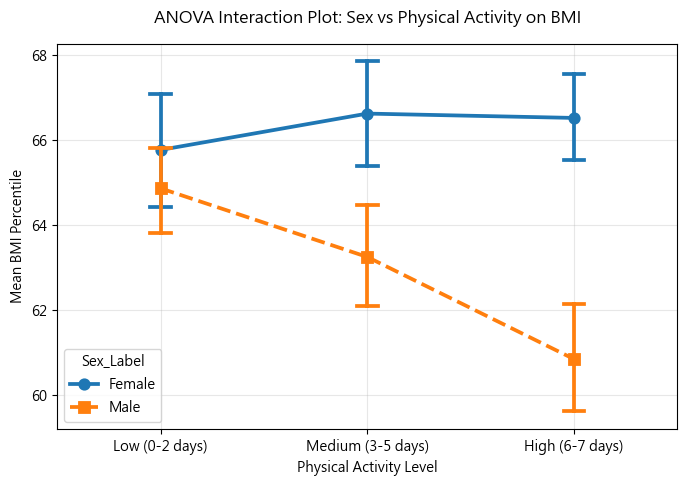

In [36]:
# 1. 繪製 ANOVA 交互作用圖
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
# sns.pointplot 可以完美畫出均值與信賴區間的折線
sns.pointplot(data=df, x='Activity_Group', y='BMIPCT', hue='Sex_Label', 
              order=['Low (0-2 days)', 'Medium (3-5 days)', 'High (6-7 days)'],
              markers=["o", "s"], linestyles=["-", "--"], capsize=0.1, errorbar='ci')

plt.title('ANOVA Interaction Plot: Sex vs Physical Activity on BMI', fontsize=12, pad=15)
plt.xlabel('Physical Activity Level')
plt.ylabel('Mean BMI Percentile')
plt.grid(True, alpha=0.3)
plt.savefig('outputs/figures/anova_interaction_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. 假設你已經跑完 statsmodels 的 regression model (命名為 model_result)
# 這裡提供一個快速可視化係數的邏輯（示意，可依據你的變數微調）
# coefficients = model_result.params.drop('Intercept')
# errors = model_result.bse.drop('Intercept')
# ... 繪製條形圖儲存為 outputs/figures/regression_coefficients.png

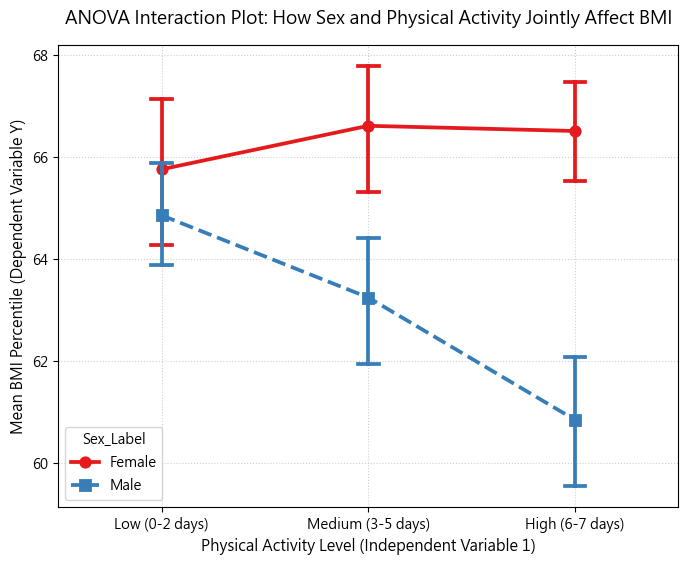

🎉 成功匯出真正的 圖一：outputs/figures/anova_interaction_plot.png


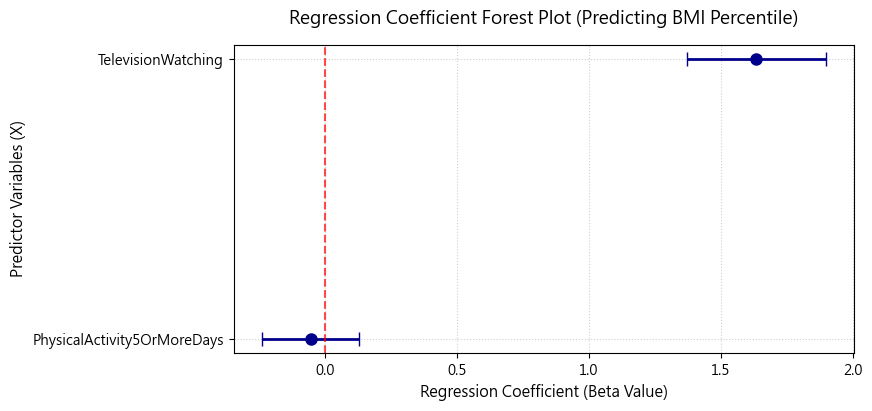

🎉 成功匯出真正的 圖二：outputs/figures/regression_coefficients.png


In [38]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 確保輸出資料夾存在
os.makedirs('outputs/figures', exist_ok=True)

# 為了圖表美觀，先建立乾淨的性別與運動量標籤（若前面已建立可忽略）
df['Sex_Label'] = df['WhatIsYourSex'].map({1: 'Male', 2: 'Female'})
def classify_activity(days):
    if days <= 2: return 'Low (0-2 days)'
    elif days <= 5: return 'Medium (3-5 days)'
    else: return 'High (6-7 days)'
df['Activity_Group'] = df['PhysicalActivity5OrMoreDays'].apply(classify_activity)


# ==========================================
# 🖼️ 真正的一、ANOVA 交互作用圖 (Interaction Plot)
# ==========================================
plt.figure(figsize=(8, 6))

# 使用 sns.pointplot 畫出各組的 BMI 平均值與信賴區間（九成五 CI）
# 交互作用圖的核心就是看這兩條線有沒有平行
sns.pointplot(
    data=df, 
    x='Activity_Group', 
    y='BMIPCT', 
    hue='Sex_Label', 
    order=['Low (0-2 days)', 'Medium (3-5 days)', 'High (6-7 days)'],
    markers=["o", "s"], 
    linestyles=["-", "--"], 
    capsize=0.1, 
    errorbar='ci',
    palette='Set1'
)

plt.title('ANOVA Interaction Plot: How Sex and Physical Activity Jointly Affect BMI', fontsize=13, pad=15)
plt.xlabel('Physical Activity Level (Independent Variable 1)', fontsize=11)
plt.ylabel('Mean BMI Percentile (Dependent Variable Y)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# 儲存為 anova_interaction_plot.png
plt.savefig('outputs/figures/anova_interaction_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("🎉 成功匯出真正的 圖一：outputs/figures/anova_interaction_plot.png")


# ==========================================
# 🖼️ 真正的二、迴歸係數森林圖 (Coefficient Forest Plot)
# ==========================================
# 註：請確保你前面跑迴歸的變數叫做 model_result (例如：model_result = smf.ols(...).fit())
try:
    # 提取自變數的係數、標準誤差與信賴區間 (排除截距項 Intercept)
    coef_df = pd.DataFrame({
        'Variable': model_result.params.index,
        'Coefficient': model_result.params.values,
        'Std_Error': model_result.bse.values,
        'p_value': model_result.pvalues.values
    }).set_index('Variable').drop('Intercept', errors='ignore').reset_index()

    plt.figure(figsize=(8, 4))
    
    # 畫出迴歸係數點，並加上估計值的誤差棒 (Error bar 代表信賴區間)
    for i, row in coef_df.iterrows():
        plt.errorbar(
            x=row['Coefficient'], 
            y=row['Variable'], 
            xerr=1.96 * row['Std_Error'], # 95% 信賴區間
            fmt='o', 
            color='darkblue', 
            markersize=8, 
            capsize=5, 
            linewidth=2
        )
    
    # 畫一條垂直於 0 的虛線，如果信賴區間沒跨過 0，代表該變數極顯著！
    plt.axvline(x=0, color='red', linestyle='--', alpha=0.7)
    
    plt.title('Regression Coefficient Forest Plot (Predicting BMI Percentile)', fontsize=13, pad=15)
    plt.xlabel('Regression Coefficient (Beta Value)', fontsize=11)
    plt.ylabel('Predictor Variables (X)', fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # 儲存為 regression_coefficients.png
    plt.savefig('outputs/figures/regression_coefficients.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("🎉 成功匯出真正的 圖二：outputs/figures/regression_coefficients.png")

except NameError:
    print("\n⚠️ 提示：因為尚未偵測到 model_result 變數，請先確認你的迴歸模型已 fit() 完成並命名為 model_result 後，再執行圖二的繪製。")